## Import Libraries

In [1]:
import sys
import importlib
import joblib
import pandas as pd
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import ScalarFormatter
import tensorflow as tf
from matplotlib.backends.backend_pdf import PdfPages
from tqdm import tqdm
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mticker

2026-09-09 11:11:39.934760: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-09 11:11:39.969456: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-09 11:11:39.969485: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-09 11:11:39.970737: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-09 11:11:39.977899: I tensorflow/core/platform/cpu_feature_guar

## Data Preparation

In [2]:
sys.path.append("../../analysis_tools")

In [3]:
from data_extraction import DataExtraction1D

In [4]:
file_path = '../../Data/1d_SWAN_Data/1d_DON_training.txt'
extractor = DataExtraction1D()
data_df = extractor.read_data_txt(file_path)

In [5]:
print(data_df)

        wind  wind_direction  initial_wave_h  initial_wave_d     dist  \
0         11             353             0.6             353      0.0   
1         11             353             0.6             353    100.0   
2         11             353             0.6             353    200.0   
3         11             353             0.6             353    300.0   
4         11             353             0.6             353    400.0   
...      ...             ...             ...             ...      ...   
902771    17               7             1.2               7  37100.0   
902772    17               7             1.2               7  37200.0   
902773    17               7             1.2               7  37300.0   
902774    17               7             1.2               7  37400.0   
902775    17               7             1.2               7  37500.0   

          depth     Hsig  RTpeak    Tm01    Tm02      FSpr      Dir  x_wforce  \
0       40.0000  0.59949  3.3437  2.8850  

In [6]:
import pickle
with open("../../Data/1d_SWAN_Data/1d_dataset.pkl", "rb") as f:
    loaded_data = pickle.load(f)

train_set = loaded_data["train"]
val_set = loaded_data["val"]
test_set = loaded_data["test"]

In [7]:
test_combination_df = pd.DataFrame(test_set, columns=["Wind Value", "Wind Direction", "Wave Height", "Wave Direction"])
print(test_combination_df)

     Wind Value  Wind Direction  Wave Height  Wave Direction
0            15             356          1.1             353
1            16             354          0.6               6
2            14               7          1.2               7
3            17             356          0.7               0
4            13               0          0.7               0
..          ...             ...          ...             ...
356          13               4          1.0               4
357          13               7          0.9             356
358          14             354          1.2               7
359          11             356          0.6               4
360          12             356          0.8             354

[361 rows x 4 columns]


## Load functions

In [9]:
def get_result(data_df, wind_value,direction_value,initial_wave_h_value,initial_wave_d_value,loc):

    filtered_df = data_df[
        (data_df['wind'] == wind_value) &
        (data_df['wind_direction'] == direction_value) &
        (data_df['initial_wave_h'] == initial_wave_h_value) &
        (data_df['initial_wave_d'] == initial_wave_d_value)
    ]
    if loc != 'entire':
        return filtered_df['x_wforce'].iloc[loc], filtered_df['y_wforce'].iloc[loc], filtered_df['Hsig'].iloc[loc], filtered_df['dist'].iloc[loc]
    else:
        return filtered_df['x_wforce'], filtered_df['y_wforce'], filtered_df['Hsig'], filtered_df['dist']

import itertools

def convert_wind_components(speed, direction):
    # Convert wind direction to radians
    direction_rad = np.deg2rad(direction)
    # Calculate x and y components of the wind speed
    x_wind = speed * np.cos(direction_rad)
    y_wind = speed * np.sin(direction_rad)
    return x_wind, y_wind
    
def load_and_scale_new_data(new_b_train, scaler_path_0_1, scaler_path_2):
    """
    Load the saved scalers and apply scaling to new data.
    
    Parameters:
    - new_b_train: np.array, new input data.
    - scaler_path_0_1: str, path to load MinMaxScaler for columns 0 and 1.
    - scaler_path_2: str, path to load MinMaxScaler for column 2.
    
    Returns:
    - new_b_train_scaled: np.array, scaled new data.
    """
    # Load the saved MinMaxScaler for columns 0 and 1
    scaler_0_1 = joblib.load(scaler_path_0_1)
    
    # Load the saved MinMaxScaler for column 2
    scaler_2 = joblib.load(scaler_path_2)
    
    
    # Apply scaling to columns 0 and 1 using the loaded scaler
    new_scaled_0_1 = scaler_0_1.transform(new_b_train[:, [0, 1]])
    
    # Apply scaling to column 2 using the loaded scaler
    new_scaled_2 = scaler_2.transform(new_b_train[:, [2]].reshape(-1, 1))
    
    
    # Combine the scaled columns back together
    new_b_train_scaled = np.hstack((new_scaled_0_1, new_scaled_2, new_b_train[:, [3, 4]]))
    
    return new_b_train_scaled


## Hsig Analysis and Model Prediction

#### L2 Relative Error Anlaysis

In [10]:
absolute_error_list = []
scenario_list = []
ground_true = []
predictions_list = []
# target_name = 'x_force'
target_name = 'hsig'

model_dir = '../../Models/1d_model_Hsig_new'

t_scaler = joblib.load(model_dir + '/t_scaler.pkl')
target_scaler = joblib.load(model_dir + '/target_scaler.pkl')
load_model = tf.keras.models.load_model(model_dir, compile=False)

if True:
    # for idx, row in tqdm(test_combination_df.iterrows(), total=len(test_combination_df), desc="Processing Hsig Scenarios"):
    for idx, row in test_combination_df.iterrows():
        # print(row)
        # print(row['Wind Value'])
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
        b_test_input,
        scaler_path_0_1=f'{model_dir }/scaler_factor_0_1.pkl',
        scaler_path_2=f'{model_dir }/scaler_factor_2.pkl'
    )
    
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
            # print('this print out hsig')
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1) 
            # print('this print out xforce')
        elif target_name == 'y_force':
            target_input = y_wforce.values.reshape(-1, 1) 
        
        o_res = load_model([b_test,t_test])
        o_res = target_scaler.inverse_transform(o_res)
        predictions_list.append(o_res)
        
        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)
        
rel_l2_list = []

# Iterate through the collected ground truth and absolute errors
for true_vec, ae_vec in zip(ground_true, absolute_error_list):
    # true_vec and ae_vec are arrays of shape (N, 1)
    
    # 1. Compute L2 norm of the absolute error (the difference)
    # ||true - pred||_2
    l2_diff = np.linalg.norm(ae_vec)
    
    # 2. Compute L2 norm of the ground truth
    # ||true||_2
    l2_truth = np.linalg.norm(true_vec)
    
    # 3. Calculate Relative L2 (protect against division by zero)
    if l2_truth > 1e-9:
        rel_l2 = (l2_diff / l2_truth) 
    else:
        rel_l2 = 0.0
        
    rel_l2_list.append(rel_l2)

# Convert to numpy array for statistics
rel_l2_arr = np.array(rel_l2_list)

print(f"--- {target_name.upper()} Model Performance ---")
print(f"Mean Rel. L2 Error:   {np.mean(rel_l2_arr):.2f}")
print(f"Median Rel. L2 Error: {np.median(rel_l2_arr):.2f}")
print(f"Max Rel. L2 Error:    {np.max(rel_l2_arr):.2f}")


# print(f"All scenario plots for Hsig have been saved in {pdf_filename}")

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
2026-09-09 11:15:07.201448: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43502 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:be:00.0, compute capability: 8.9
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://

--- HSIG Model Performance ---
Mean Rel. L2 Error:   0.00
Median Rel. L2 Error: 0.00
Max Rel. L2 Error:    0.01


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


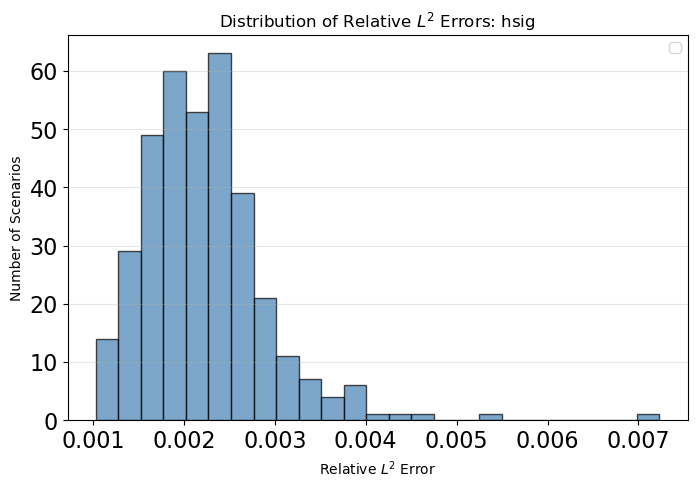

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(rel_l2_arr, bins=25, color='steelblue', edgecolor='black', alpha=0.7)

plt.title(f"Distribution of Relative $L^2$ Errors: {target_name}")
plt.xlabel("Relative $L^2$ Error")
plt.ylabel("Number of Scenarios")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
# plt.savefig("1d_Hsig_Distribution.pdf")
plt.show()

In [12]:
rel_l2_arr = np.array(rel_l2_list)
sorted_indices = np.argsort(rel_l2_arr)

best_3 = sorted_indices[:3]
worst_3 = sorted_indices[-3:][::-1] # Reverse to show the absolute worst first

In [13]:
print(best_3)
print(worst_3)

[ 82 206 319]
[336 312 244]


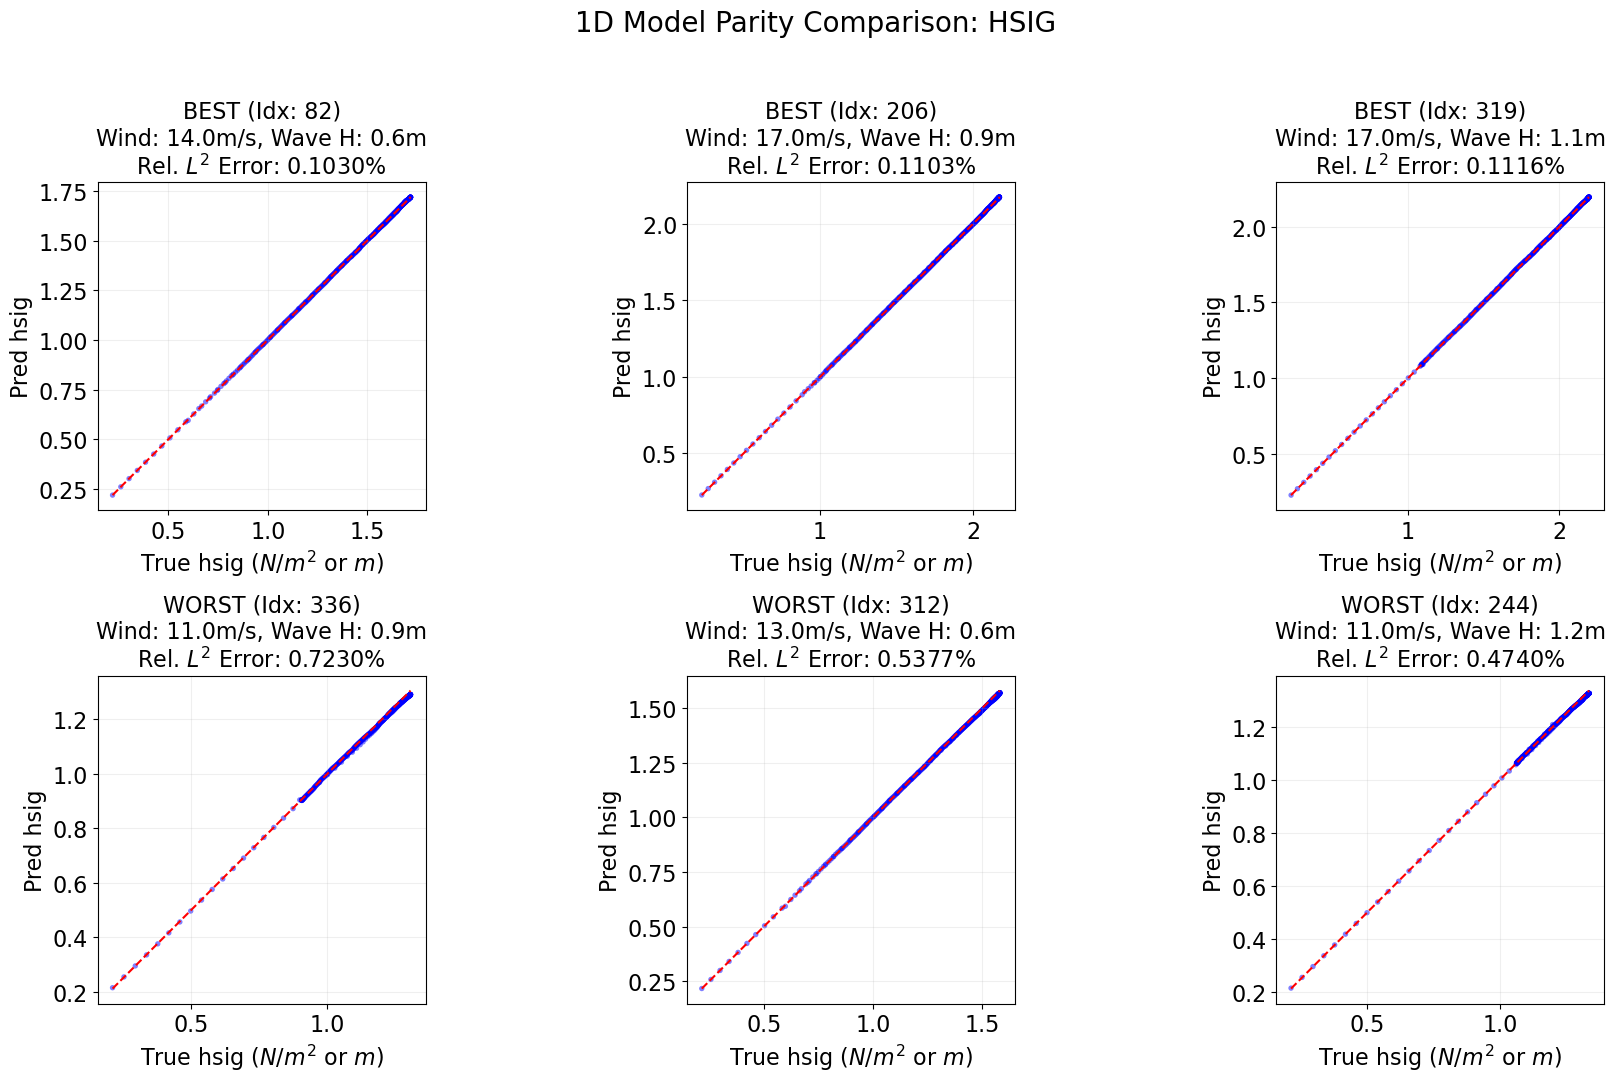

In [14]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(18, 11))
plt.subplots_adjust(hspace=0.4, wspace=0.3)


plot_configs = []
for i, idx in enumerate(best_3):
    plot_configs.append((idx, axs[0, i], "BEST", "teal"))
for i, idx in enumerate(worst_3):
    plot_configs.append((idx, axs[1, i], "WORST", "crimson"))

for idx, ax, prefix, color in plot_configs:
    # 1. Get the data for this scenario
    true = ground_true[idx].flatten()
    ae = absolute_error_list[idx].flatten()
    pred = predictions_list[idx].flatten()
    

    ax.scatter(true, pred, alpha=0.5, s=15, color='blue', edgecolors='none')
    
    limits = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(limits, limits, color='red', linestyle='--', linewidth=1.5, label="1:1 Match")
    
    # 4. Scenario Metadata for Title
    sw, sd, wh, wd = scenario_list[idx]
    err = rel_l2_arr[idx] * 100
    
    ax.set_title(f"{prefix} (Idx: {idx})\nWind: {sw}m/s, Wave H: {wh}m\nRel. $L^2$ Error: {err:.4f}%", fontsize=16)
    ax.set_xlabel(f"True {target_name} ($N/m^2$ or $m$)", fontsize=16)
    ax.set_ylabel(f"Pred {target_name}", fontsize=16)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_aspect('equal')

fig.suptitle(f"1D Model Parity Comparison: {target_name.upper()}", fontsize=20, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("1d_Hsig_Parity.pdf")

plt.show()



In [15]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[0]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 336) ---
Target Variable: HSIG
Scenario Info:   Wind 11.0m/s 353.0°, Wave 0.9m 6.0°
--------------------------------------------------
Max Absolute Error:  0.016125
Mean Absolute Error: 0.006999
RMSE:                0.008305
Relative L2 Error:   0.72%


In [17]:
# 1. Find the index where the error is at its maximum
max_err_idx = np.argmax(ae_worst)

# 2. Get the physical X-coordinate (Distance) from dist_x
# Use .iloc if dist_x is a pandas Series/DataFrame
max_err_dist = dist_x.iloc[max_err_idx] 

# 3. Get the Ground Truth value at that specific location
max_err_truth = true_worst[max_err_idx]

# 4. Get the DON Prediction value at that specific location
# (Calculated as Truth +/- Error depending on direction, or just from o_res)
max_err_pred = o_res.flatten()[max_err_idx]

print(f"--- Peak Error Details (Worst Case) ---")
print(f"Location of Max Error:  x = {max_err_dist:.2f} m")
print(f"Max Absolute Error:     {max_ae_val:.6f}")
print(f"Ground Truth at x:      {max_err_truth:.6f}")
print(f"DON Prediction at x:    {max_err_pred:.6f}")

--- Peak Error Details (Worst Case) ---
Location of Max Error:  x = 28000.00 m
Max Absolute Error:     0.016125
Ground Truth at x:      1.302500
DON Prediction at x:    1.435974


In [18]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[1]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 312) ---
Target Variable: HSIG
Scenario Info:   Wind 13.0m/s 356.0°, Wave 0.6m 0.0°
--------------------------------------------------
Max Absolute Error:  0.015419
Mean Absolute Error: 0.005502
RMSE:                0.007133
Relative L2 Error:   0.54%


In [19]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[2]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 244) ---
Target Variable: HSIG
Scenario Info:   Wind 11.0m/s 353.0°, Wave 1.2m 6.0°
--------------------------------------------------
Max Absolute Error:  0.011124
Mean Absolute Error: 0.004403
RMSE:                0.005714
Relative L2 Error:   0.47%


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


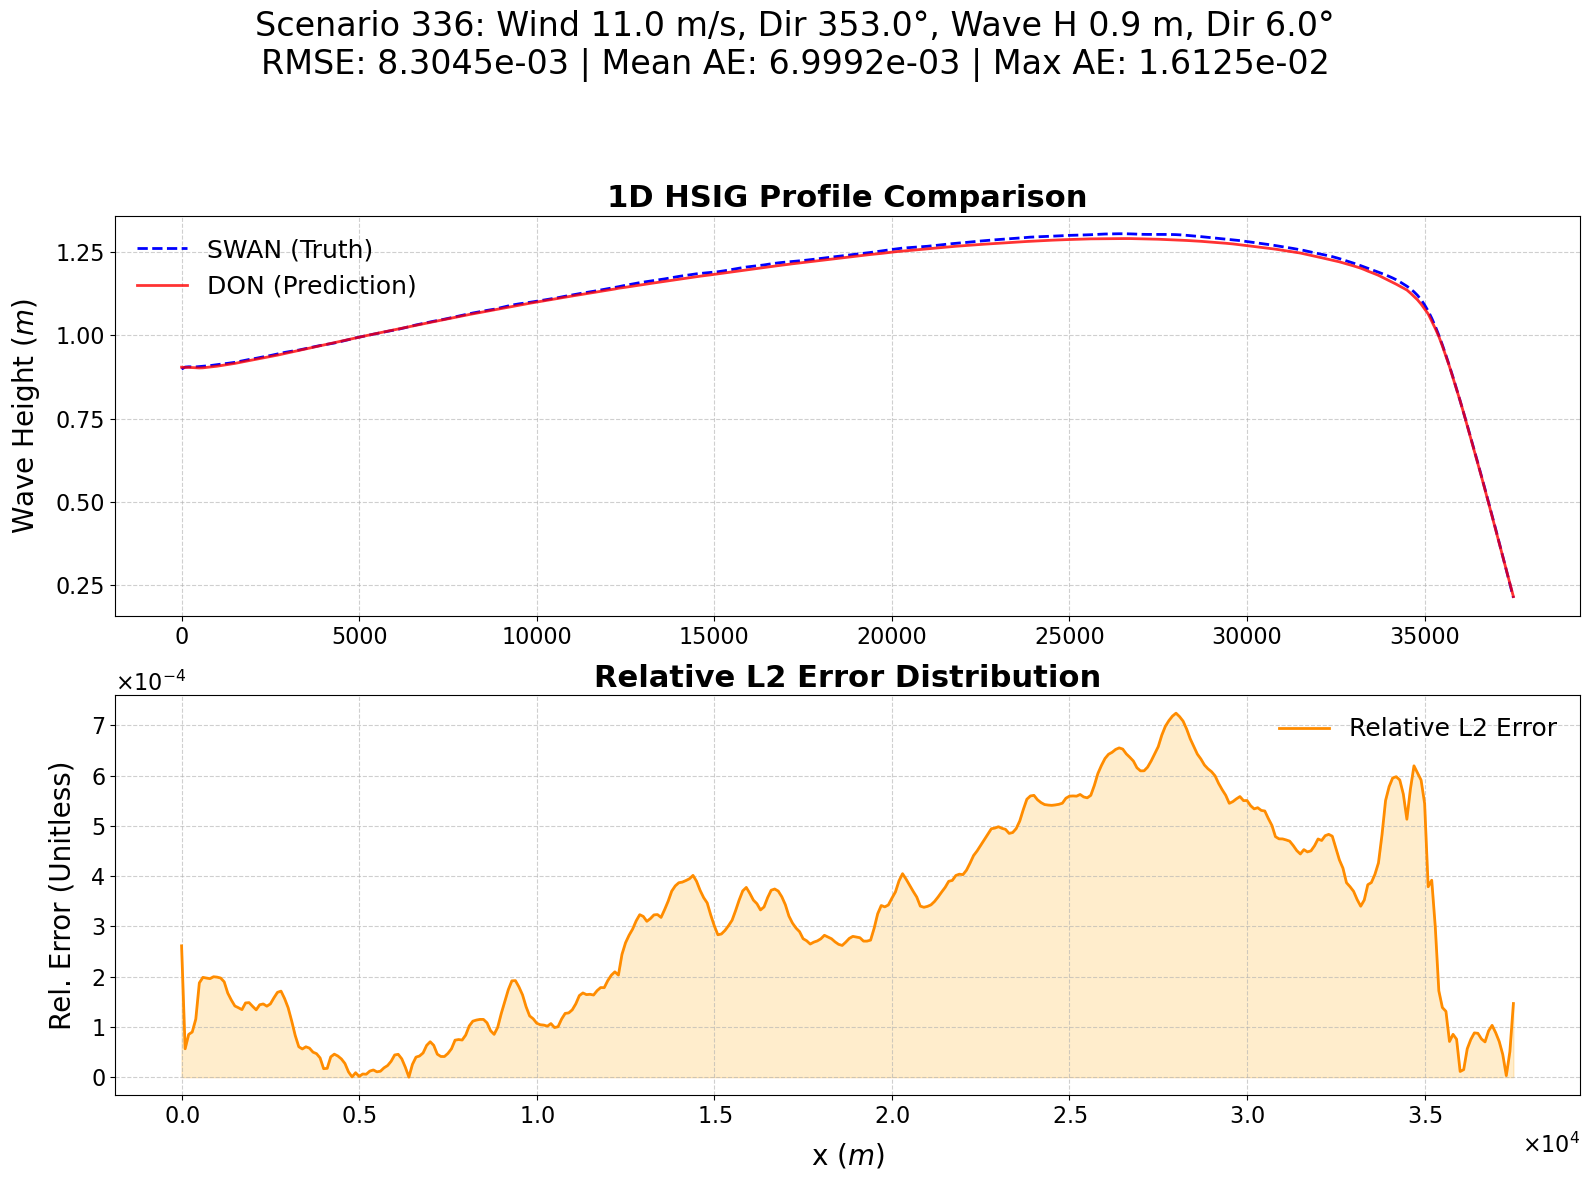

Plotting complete for Scenario 336.
------------------------------
PEAK ERROR ANALYSIS (Scenario 336)
Location (x):          28000.00 m
Max Absolute Error:    0.016125
True vs Pred at Peak:  1.3025 vs 1.2864
Point Rel. L2 Error:   0.0007
------------------------------


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import os

# --- 1. Plotting Configuration ---
plot_params = {
    "lines.linewidth": 2,
    "lines.markersize": 5,
    "legend.fontsize": 18,
    "legend.frameon": False,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "figure.figsize": (16, 12),
    "axes.labelpad": 10,
}

# --- 2. Data Selection & Prediction ---
idx = 336  # Target Scenario Index
target_name = 'hsig'  # Options: 'hsig', 'x_force', 'y_force'

row = test_combination_df.iloc[idx]

# Get SWAN Truth Data
x_wforce, y_wforce, hsig, dist_x = get_result(
    data_df, row['Wind Value'], row['Wind Direction'],
    row['Wave Height'], row['Wave Direction'], loc='entire'
)

# Prepare Model Input
x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
sin_wave_dir = np.sin(np.radians(row['Wave Direction']))

b_test_input = np.array([
    [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
    for _ in range(len(dist_x))
])

# Scaling and Prediction
b_test = load_and_scale_new_data(
    b_test_input,
    scaler_path_0_1=f'{model_dir}/scaler_factor_0_1.pkl',
    scaler_path_2=f'{model_dir}/scaler_factor_2.pkl'
)

t_test_input = dist_x.values.reshape(-1, 1)
t_test = t_scaler.transform(t_test_input)

# Target Assignment
if target_name == 'hsig':
    target_input = hsig.values.reshape(-1, 1)
    y_label = "Wave Height ($m$)"
elif target_name == 'x_force':
    target_input = x_wforce.values.reshape(-1, 1)
    y_label = "X-Force ($N/m^2$)"
elif target_name == 'y_force':
    target_input = y_wforce.values.reshape(-1, 1)
    y_label = "Y-Force ($N/m^2$)"

o_res = load_model([b_test, t_test])
o_res = target_scaler.inverse_transform(o_res)

# --- 3. Error Calculations ---
# Point-wise Absolute Error
absolute_error = np.abs(o_res - target_input)
max_err_idx = np.argmax(absolute_error)

max_ae_val = absolute_error[max_err_idx][0]  # The peak error value
max_err_loc = t_test_input[max_err_idx][0]   # The distance (x) where it occurs
peak_truth = target_input[max_err_idx][0]    # The true value at that x
peak_pred = o_res[max_err_idx][0]            # The DON prediction at that x


# Point-wise Relative L2 Field
# Normalized by the Global L2 Norm of the Truth for this scenario
l2_norm_truth = np.linalg.norm(target_input)
rel_l2_field = absolute_error / (l2_norm_truth + 1e-10)
peak_rel_l2_val = rel_l2_field[max_err_idx][0]

# Scalar Metrics for Title
rmse = np.sqrt(np.mean((target_input - o_res)**2))
mean_ae = np.mean(absolute_error)
max_ae = np.max(absolute_error)

# --- 4. Final Plotting ---
with plt.rc_context(plot_params):
    fig, axes = plt.subplots(nrows=2, ncols=1)
    plt.subplots_adjust(hspace=0.4)

    # Subplot 0: Comparison (SWAN vs DON)
    axes[0].plot(t_test_input, target_input, label='SWAN (Truth)', color='blue', linestyle='--')
    axes[0].plot(t_test_input, o_res, label='DON (Prediction)', color='red', alpha=0.8)
    axes[0].set_title(f"1D {target_name.upper()} Profile Comparison", fontweight='bold')
    axes[0].set_ylabel(y_label)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Optional: adjust y-axis ticks based on target scale
    if target_name == 'hsig':
        axes[0].yaxis.set_major_locator(MultipleLocator(0.25))
    else:
        # For forces, use scientific notation
        axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Subplot 1: Relative L2 Error Field
    axes[1].plot(t_test_input, rel_l2_field, label='Relative L2 Error', color='darkorange')
    axes[1].fill_between(t_test_input.flatten(), rel_l2_field.flatten(), color='orange', alpha=0.2)
    
    axes[1].set_title("Relative L2 Error Distribution", fontweight='bold')
    axes[1].set_xlabel("x ($m$)")
    axes[1].set_ylabel("Rel. Error (Unitless)")
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Format Y-axis for Relative Error (Small values)
    axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Format X-axis for Distance (Meters)
    axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0, 4))

    # Global Figure Heading
    plt.suptitle(
        f"Scenario {idx}: Wind {row['Wind Value']} m/s, Dir {row['Wind Direction']}°, "
        f"Wave H {row['Wave Height']} m, Dir {row['Wave Direction']}°\n"
        f"RMSE: {rmse:.4e} | Mean AE: {mean_ae:.4e} | Max AE: {max_ae:.4e}",
        fontsize=24, y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    # plt.savefig("Hsig_Worst_Relativel2Error_scenarios.pdf")
    plt.show()

print(f"Plotting complete for Scenario {idx}.")

print("-" * 30)
print(f"PEAK ERROR ANALYSIS (Scenario {idx})")
print(f"Location (x):          {max_err_loc:.2f} m")
print(f"Max Absolute Error:    {max_ae_val:.6f}")
print(f"True vs Pred at Peak:  {peak_truth:.4f} vs {peak_pred:.4f}")
print(f"Point Rel. L2 Error:   {peak_rel_l2_val:.4f}")
print("-" * 30)

#### Generate and Save Test-Scenario Predictions (PDF)

In [21]:
# Try this first to save the output as a PDF and prevent the machine from freezing.
test_combination_df_top5 = test_combination_df.head(5)  

In [22]:
absolute_error_list = []
scenario_list = []
ground_true = []
target_name = 'hsig'

model_dir = '../../Models/1d_model_Hsig_new'

t_scaler = joblib.load(model_dir + '/t_scaler.pkl')
target_scaler = joblib.load(model_dir + '/target_scaler.pkl')
load_model = tf.keras.models.load_model(model_dir, compile=False)

# Directory to save plots
output_dir = "."
os.makedirs(output_dir, exist_ok=True)
pdf_filename = os.path.join(output_dir, "1d_test_scenarios_hsig.pdf")  # Updated file name

with PdfPages(pdf_filename) as pdf:
    for idx, row in tqdm(test_combination_df_top5.iterrows(), total=len(test_combination_df_top5), desc="Processing Hsig Scenarios"):
    # for idx, row in tqdm(test_combination_df.iterrows(), total=len(test_combination_df), desc="Processing Hsig Scenarios"):
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
        b_test_input,
        scaler_path_0_1 = model_dir + '/scaler_factor_0_1.pkl',
        scaler_path_2= model_dir + '/scaler_factor_2.pkl', 
    )
    
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
            y_label = "Wave Height ($m$)"
            # print('this print out hsig')
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1) 
            y_label = "X-Force ($N/m^2$)"
            # print('this print out xforce')
        
        o_res = load_model([b_test,t_test])
        o_res = target_scaler.inverse_transform(o_res)
        
        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)
        
        l2_norm_truth = np.linalg.norm(target_input)
        rel_l2_field = absolute_error / (l2_norm_truth + 1e-10)

        text_size = 18
    
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))
        
        axes[0].plot(t_test_input, target_input, label='SWAN (Truth)', color='blue', linestyle='--')
        axes[0].plot(t_test_input, o_res, label='DON (Prediction)', color='red', alpha=0.7)
        axes[0].set_title(f"Profile Comparison: {target_name.upper()}", fontweight='bold')
        axes[0].set_ylabel(y_label)
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # Subplot 1: Relative L2 Error Field
        axes[1].plot(t_test_input, rel_l2_field, label='Relative $L^2$ Error', color='darkorange')
        axes[1].fill_between(t_test_input.flatten(), rel_l2_field.flatten(), color='orange', alpha=0.15)
        axes[1].set_title("Relative $L^2$ Error Distribution", fontweight='bold')
        axes[1].set_xlabel("x ($m$)")
        axes[1].set_ylabel("Rel. Error")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

        # Scientific notation for error and distance
        axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,4))
    
        plt.tight_layout(rect=[0, 0, 1, 0.96]) 
        plt.suptitle(
            f"Scenario {idx}: "
            f"Wind {row['Wind Value']} m/s, "
            f"Dir {row['Wind Direction']}°, "
            f"Wave H {row['Wave Height']} m, "
            f"Dir {row['Wave Direction']}°",
            fontsize=text_size + 1
        )
                
      
        pdf.savefig(fig)
        plt.close(fig)

print(f"All scenario plots for Hsig have been saved in {pdf_filename}")

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Processing Hsig Scenarios:   0%|                                                              | 0/5 [00:00<?, ?it/s]/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Processing Hsig Scenarios:  20%|██

All scenario plots for Hsig have been saved in ./1d_test_scenarios_hsig.pdf


## Forces Analysis and Model Prediction

#### L2 Relative Error Anlaysis

In [23]:
absolute_error_list = []
scenario_list = []
ground_true = []
target_name = 'x_force'
# target_name = 'hsig'
predictions_list = []

model_dir = '/workspace/shukaic/github/archive/DON_SWAN/1d_model_forces_new'

t_scaler = joblib.load(model_dir + '/t_scaler.pkl')
target_scaler = joblib.load(model_dir + '/target_scaler.pkl')
load_model = tf.keras.models.load_model(model_dir, compile=False)

# pdf_filename = os.path.join(output_dir, "1d_test_scenarios_hsig_boldText_new.pdf")  # Updated file name

# with PdfPages(pdf_filename) as pdf:
if True:
    # for idx, row in tqdm(test_combination_df.iterrows(), total=len(test_combination_df), desc="Processing Hsig Scenarios"):
    for idx, row in test_combination_df.iterrows():
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
        b_test_input,
        scaler_path_0_1=f'{model_dir}/scaler_factor_0_1.pkl',
        scaler_path_2=f'{model_dir}/scaler_factor_2.pkl'
    )
    
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
            # print('this print out hsig')
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1) 
            # print('this print out xforce')
        elif target_name == 'y_force':
            target_input = y_wforce.values.reshape(-1, 1) 
        
        o_res = load_model([b_test,t_test])
        o_res = target_scaler.inverse_transform(o_res)
        
        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)
        predictions_list.append(o_res)

    rel_l2_list = []
    
    # Iterate through the collected ground truth and absolute errors
    for true_vec, ae_vec in zip(ground_true, absolute_error_list):
        # true_vec and ae_vec are arrays of shape (N, 1)
        
        # 1. Compute L2 norm of the absolute error (the difference)
        # ||true - pred||_2
        l2_diff = np.linalg.norm(ae_vec)
        
        # 2. Compute L2 norm of the ground truth
        # ||true||_2
        l2_truth = np.linalg.norm(true_vec)
        
        # 3. Calculate Relative L2 (protect against division by zero)
        if l2_truth > 1e-9:
            rel_l2 = (l2_diff / l2_truth) 
        else:
            rel_l2 = 0.0
            
        rel_l2_list.append(rel_l2)
    
    # Convert to numpy array for statistics
    rel_l2_arr = np.array(rel_l2_list)
    
    print(f"--- {target_name.upper()} Model Performance ---")
    print(f"Mean Rel. L2 Error:   {np.mean(rel_l2_arr):.2f}%")
    print(f"Median Rel. L2 Error: {np.median(rel_l2_arr):.2f}%")
    print(f"Max Rel. L2 Error:    {np.max(rel_l2_arr):.2f}%")


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

--- X_FORCE Model Performance ---
Mean Rel. L2 Error:   0.03%
Median Rel. L2 Error: 0.02%
Max Rel. L2 Error:    0.06%


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinM

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


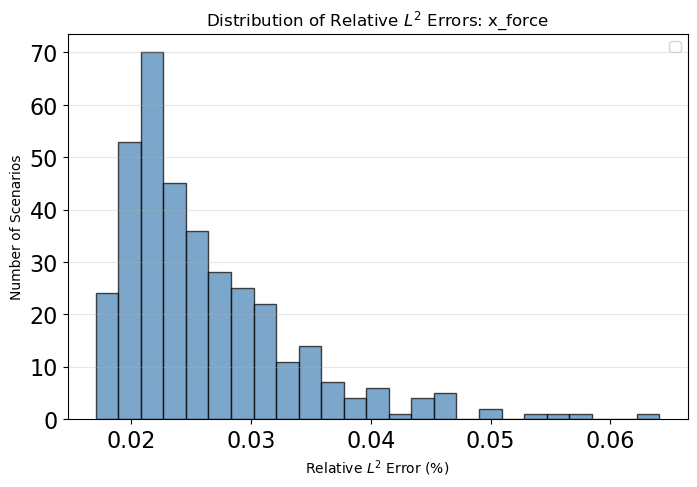

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(rel_l2_arr, bins=25, color='steelblue', edgecolor='black', alpha=0.7)

# # Add statistics lines
# plt.axvline(np.mean(rel_l2_arr), color='red', linestyle='--', label=f'Mean: {np.mean(rel_l2_arr):.2f}%')
# plt.axvline(np.median(rel_l2_arr), color='green', linestyle='-', label=f'Median: {np.median(rel_l2_arr):.2f}%')

plt.title(f"Distribution of Relative $L^2$ Errors: {target_name}")
plt.xlabel("Relative $L^2$ Error (%)")
plt.ylabel("Number of Scenarios")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tick_params(axis='both', labelsize=16)
# plt.savefig("1d_forces_Distribution.pdf")
plt.show()

In [25]:
# Convert your collected lists to numpy arrays for plotting
# ground_true is a list of (N, 1) arrays
# predictions can be reconstructed: pred = true - absolute_error

rel_l2_arr = np.array(rel_l2_list)
sorted_indices = np.argsort(rel_l2_arr)

best_3 = sorted_indices[:3]
worst_3 = sorted_indices[-3:][::-1] # Reverse to show the absolute worst first
print(best_3 )
print(worst_3)

[145 206 128]
[329  38 298]


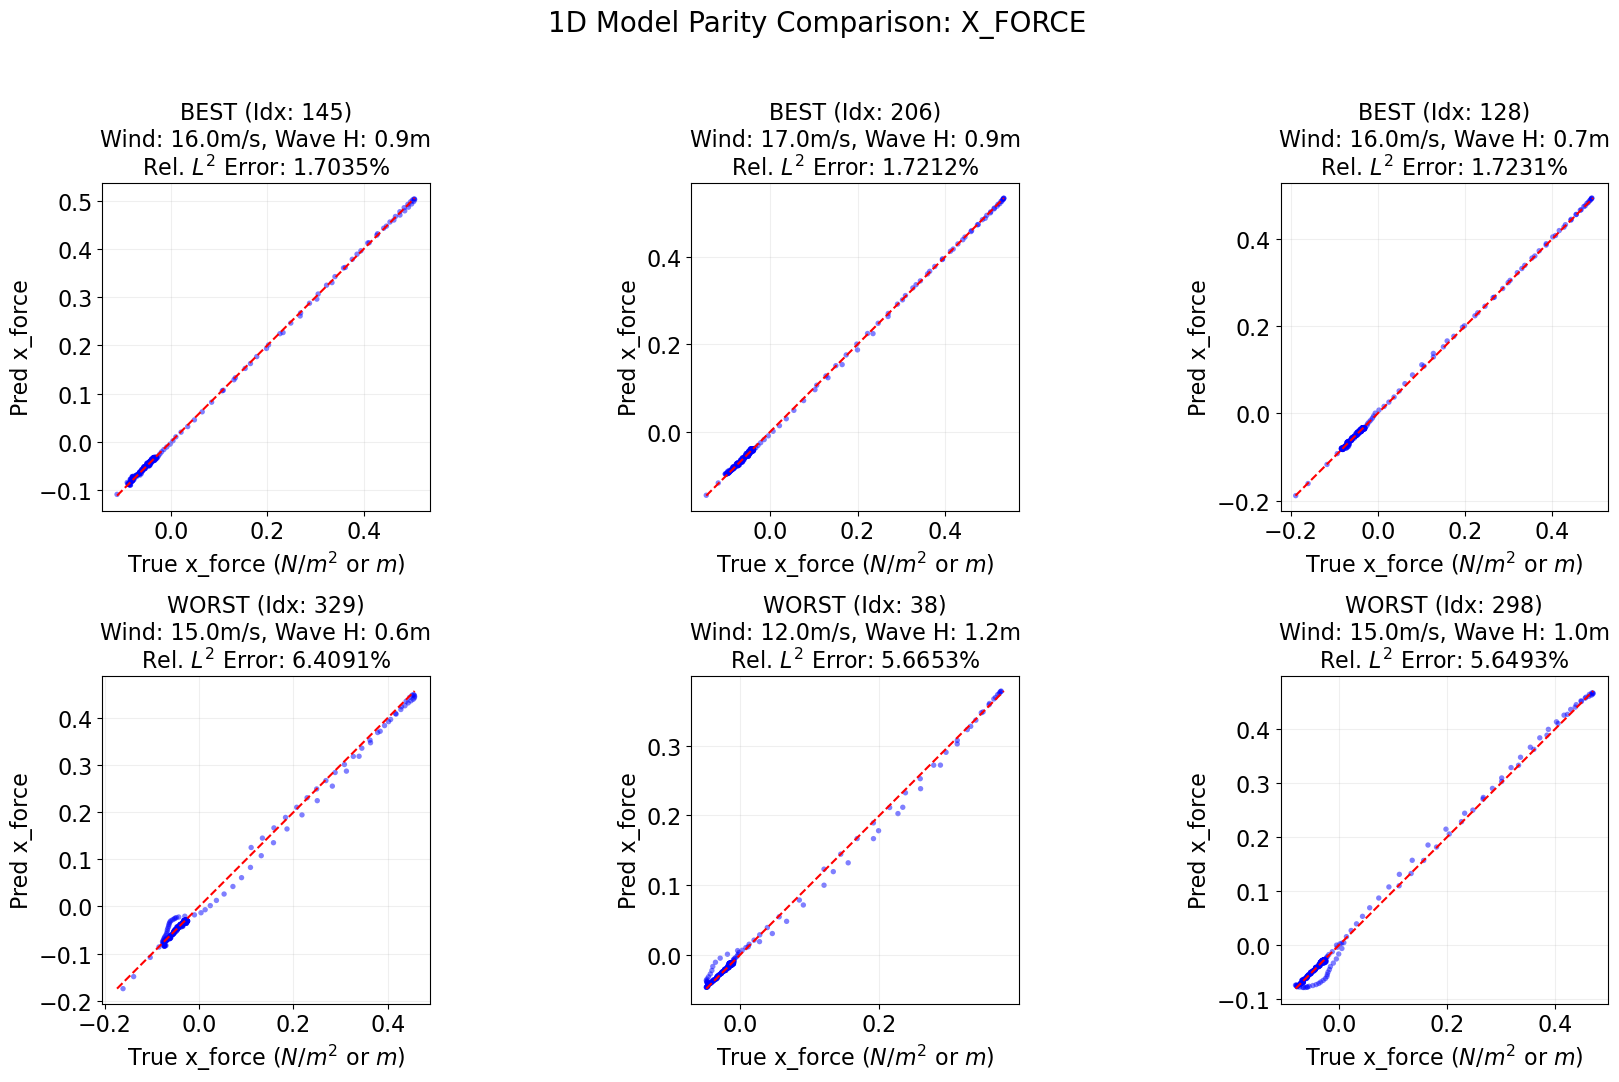

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(18, 11))
plt.subplots_adjust(hspace=0.4, wspace=0.3)


plot_configs = []
for i, idx in enumerate(best_3):
    plot_configs.append((idx, axs[0, i], "BEST", "teal"))
for i, idx in enumerate(worst_3):
    plot_configs.append((idx, axs[1, i], "WORST", "crimson"))

for idx, ax, prefix, color in plot_configs:
    # 1. Get the data for this scenario
    true = ground_true[idx].flatten()
    ae = absolute_error_list[idx].flatten()
    pred = predictions_list[idx].flatten()
    

    ax.scatter(true, pred, alpha=0.5, s=15, color='blue', edgecolors='none')
    
    limits = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(limits, limits, color='red', linestyle='--', linewidth=1.5, label="1:1 Match")
    
    # 4. Scenario Metadata for Title
    sw, sd, wh, wd = scenario_list[idx]
    err = rel_l2_arr[idx] * 100
    
    ax.set_title(f"{prefix} (Idx: {idx})\nWind: {sw}m/s, Wave H: {wh}m\nRel. $L^2$ Error: {err:.4f}%", fontsize=16)
    ax.set_xlabel(f"True {target_name} ($N/m^2$ or $m$)", fontsize=16)
    ax.set_ylabel(f"Pred {target_name}", fontsize=16)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='both', labelsize=16)
    ax.set_aspect('equal')

fig.suptitle(f"1D Model Parity Comparison: {target_name.upper()}", fontsize=20, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("1d_Forces_Parity.pdf")

plt.show()



In [27]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[0]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 329) ---
Target Variable: X_FORCE
Scenario Info:   Wind 15.0m/s 353.0°, Wave 0.6m 7.0°
--------------------------------------------------
Max Absolute Error:  0.029771
Mean Absolute Error: 0.004845
RMSE:                0.008037
Relative L2 Error:   6.41%


In [28]:
# 1. Find the index where the error is at its maximum
max_err_idx = np.argmax(ae_worst)

# 2. Get the physical X-coordinate (Distance) from dist_x
# Use .iloc if dist_x is a pandas Series/DataFrame
max_err_dist = dist_x.iloc[max_err_idx] 

# 3. Get the Ground Truth value at that specific location
max_err_truth = true_worst[max_err_idx]

# 4. Get the DON Prediction value at that specific location
# (Calculated as Truth +/- Error depending on direction, or just from o_res)
max_err_pred = o_res.flatten()[max_err_idx]

print(f"--- Peak Error Details (Worst Case) ---")
print(f"Location of Max Error:  x = {max_err_dist:.2f} m")
print(f"Max Absolute Error:     {max_ae_val:.6f}")
print(f"Ground Truth at x:      {max_err_truth:.6f}")
print(f"DON Prediction at x:    {max_err_pred:.6f}")

--- Peak Error Details (Worst Case) ---
Location of Max Error:  x = 31800.00 m
Max Absolute Error:     0.029771
Ground Truth at x:      -0.059840
DON Prediction at x:    -0.044663


In [29]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[1]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 38) ---
Target Variable: X_FORCE
Scenario Info:   Wind 12.0m/s 0.0°, Wave 1.2m 0.0°
--------------------------------------------------
Max Absolute Error:  0.024666
Mean Absolute Error: 0.002578
RMSE:                0.005072
Relative L2 Error:   5.67%


In [30]:
# 1. Identify the index of the absolute worst scenario
# 'worst_3' was sorted based on Relative L2, so worst_3[0] is the highest error
worst_idx = worst_3[2]

# 2. Extract the relevant data for this specific scenario
# ground_true[worst_idx] is the SWAN data
# absolute_error_list[worst_idx] is |SWAN - DON|
true_worst = ground_true[worst_idx].flatten()
ae_worst = absolute_error_list[worst_idx].flatten()

# 3. Calculate the Metrics
max_ae_val = np.max(ae_worst)
mean_ae_val = np.mean(ae_worst)
# RMSE = sqrt(mean(error^2))
rmse_val = np.sqrt(np.mean(ae_worst**2))

# 4. Get Scenario Info for context
info = scenario_list[worst_idx]

print(f"--- Performance Metrics for the WORST Case (Index {worst_idx}) ---")
print(f"Target Variable: {target_name.upper()}")
print(f"Scenario Info:   Wind {info[0]}m/s {info[1]}°, Wave {info[2]}m {info[3]}°")
print("-" * 50)
print(f"Max Absolute Error:  {max_ae_val:.6f}")
print(f"Mean Absolute Error: {mean_ae_val:.6f}")
print(f"RMSE:                {rmse_val:.6f}")
print(f"Relative L2 Error:   {rel_l2_arr[worst_idx]*100:.2f}%")

--- Performance Metrics for the WORST Case (Index 298) ---
Target Variable: X_FORCE
Scenario Info:   Wind 15.0m/s 354.0°, Wave 1.0m 7.0°
--------------------------------------------------
Max Absolute Error:  0.036645
Mean Absolute Error: 0.003473
RMSE:                0.007132
Relative L2 Error:   5.65%


/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


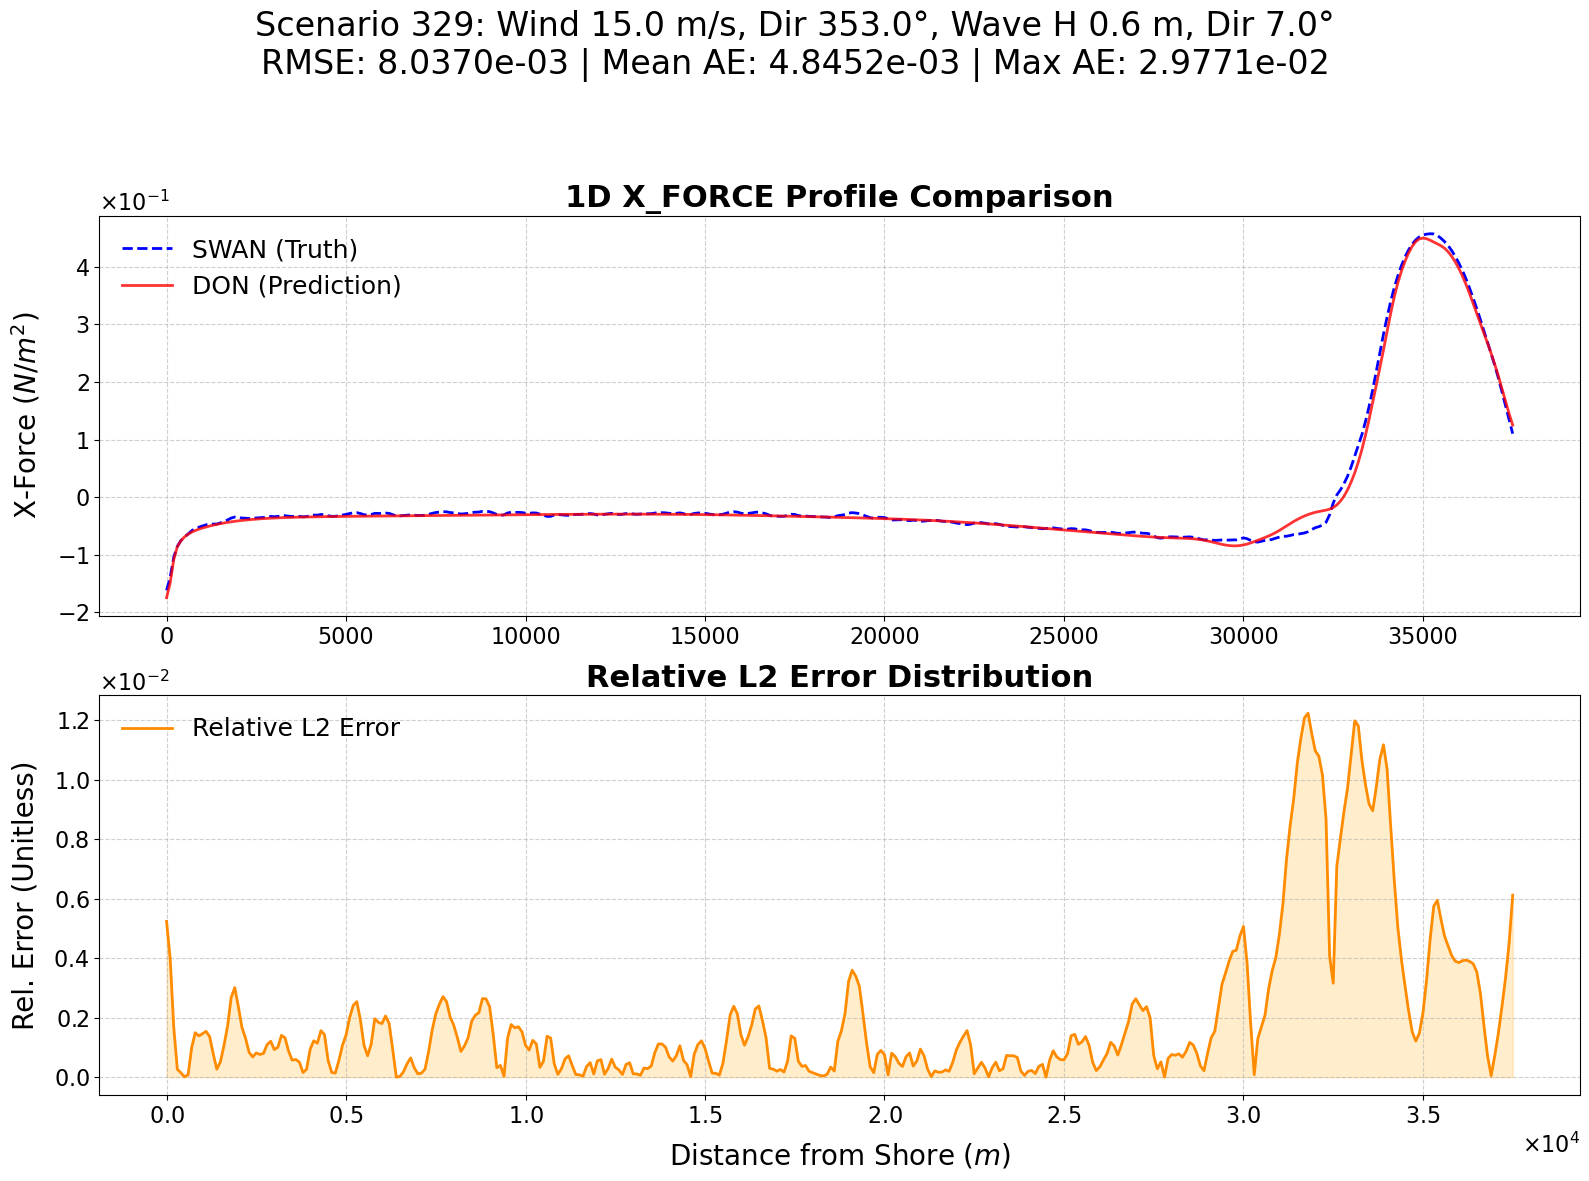

Plotting complete for Scenario 329.
------------------------------
PEAK ERROR ANALYSIS (Scenario 329)
Location (x):          31800.00 m
Max Absolute Error:    0.029771
True vs Pred at Peak:  -0.0598 vs -0.0301
Point Rel. L2 Error:   0.0122
------------------------------


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import MultipleLocator, ScalarFormatter
import os

# --- 1. Plotting Configuration ---
plot_params = {
    "lines.linewidth": 2,
    "lines.markersize": 5,
    "legend.fontsize": 18,
    "legend.frameon": False,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "figure.figsize": (16, 12),
    "axes.labelpad": 10,
}

# --- 2. Data Selection & Prediction ---
idx = worst_3[0]  # Target Scenario Index
target_name = 'x_force'  # Options: 'hsig', 'x_force', 'y_force'

row = test_combination_df.iloc[idx]

# Get SWAN Truth Data
x_wforce, y_wforce, hsig, dist_x = get_result(
    data_df, row['Wind Value'], row['Wind Direction'],
    row['Wave Height'], row['Wave Direction'], loc='entire'
)

# Prepare Model Input
x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
sin_wave_dir = np.sin(np.radians(row['Wave Direction']))

b_test_input = np.array([
    [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
    for _ in range(len(dist_x))
])

# Scaling and Prediction
b_test = load_and_scale_new_data(
    b_test_input,
    scaler_path_0_1=f'{model_dir}/scaler_factor_0_1.pkl',
    scaler_path_2=f'{model_dir}/scaler_factor_2.pkl'
)

t_test_input = dist_x.values.reshape(-1, 1)
t_test = t_scaler.transform(t_test_input)

# Target Assignment
if target_name == 'hsig':
    target_input = hsig.values.reshape(-1, 1)
    y_label = "Wave Height ($m$)"
elif target_name == 'x_force':
    target_input = x_wforce.values.reshape(-1, 1)
    y_label = "X-Force ($N/m^2$)"
elif target_name == 'y_force':
    target_input = y_wforce.values.reshape(-1, 1)
    y_label = "Y-Force ($N/m^2$)"

o_res = load_model([b_test, t_test])
o_res = target_scaler.inverse_transform(o_res)

# --- 3. Error Calculations ---
# Point-wise Absolute Error
absolute_error = np.abs(o_res - target_input)
max_err_idx = np.argmax(absolute_error)

# Point-wise Relative L2 Field
# Normalized by the Global L2 Norm of the Truth for this scenario
l2_norm_truth = np.linalg.norm(target_input)
rel_l2_field = absolute_error / (l2_norm_truth + 1e-10)

max_ae_val = absolute_error[max_err_idx][0]  # The peak error value
max_err_loc = t_test_input[max_err_idx][0]   # The distance (x) where it occurs
peak_truth = target_input[max_err_idx][0]    # The true value at that x
peak_pred = o_res[max_err_idx][0]            # The DON prediction at that x
peak_rel_l2_val = rel_l2_field[max_err_idx][0]


# Scalar Metrics for Title
rmse = np.sqrt(np.mean((target_input - o_res)**2))
mean_ae = np.mean(absolute_error)
max_ae = np.max(absolute_error)

# --- 4. Final Plotting ---
with plt.rc_context(plot_params):
    fig, axes = plt.subplots(nrows=2, ncols=1)
    plt.subplots_adjust(hspace=0.4)

    # Subplot 0: Comparison (SWAN vs DON)
    axes[0].plot(t_test_input, target_input, label='SWAN (Truth)', color='blue', linestyle='--')
    axes[0].plot(t_test_input, o_res, label='DON (Prediction)', color='red', alpha=0.8)
    axes[0].set_title(f"1D {target_name.upper()} Profile Comparison", fontweight='bold')
    axes[0].set_ylabel(y_label)
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Optional: adjust y-axis ticks based on target scale
    if target_name == 'hsig':
        axes[0].yaxis.set_major_locator(MultipleLocator(0.25))
    else:
        # For forces, use scientific notation
        axes[0].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

    # Subplot 1: Relative L2 Error Field
    axes[1].plot(t_test_input, rel_l2_field, label='Relative L2 Error', color='darkorange')
    axes[1].fill_between(t_test_input.flatten(), rel_l2_field.flatten(), color='orange', alpha=0.2)
    
    axes[1].set_title("Relative L2 Error Distribution", fontweight='bold')
    axes[1].set_xlabel("Distance from Shore ($m$)")
    axes[1].set_ylabel("Rel. Error (Unitless)")
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    # Format Y-axis for Relative Error (Small values)
    axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    # Format X-axis for Distance (Meters)
    axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0, 4))

    # Global Figure Heading
    plt.suptitle(
        f"Scenario {idx}: Wind {row['Wind Value']} m/s, Dir {row['Wind Direction']}°, "
        f"Wave H {row['Wave Height']} m, Dir {row['Wave Direction']}°\n"
        f"RMSE: {rmse:.4e} | Mean AE: {mean_ae:.4e} | Max AE: {max_ae:.4e}",
        fontsize=24, y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    # plt.savefig("Forces_Worst_Relativel2Error_scenarios.pdf")
    plt.show()

print(f"Plotting complete for Scenario {idx}.")
print("-" * 30)
print(f"PEAK ERROR ANALYSIS (Scenario {idx})")
print(f"Location (x):          {max_err_loc:.2f} m")
print(f"Max Absolute Error:    {max_ae_val:.6f}")
print(f"True vs Pred at Peak:  {peak_truth:.4f} vs {peak_pred:.4f}")
print(f"Point Rel. L2 Error:   {peak_rel_l2_val:.4f}")
print("-" * 30)

#### Generate and Save Test-Scenario Predictions (PDF)

In [33]:
# Try this first to save the output as a PDF and prevent the machine from freezing.
test_combination_df_top5 = test_combination_df.head(5)  

In [34]:
absolute_error_list = []
scenario_list = []
ground_true = []

target_name = 'x_force'
model_dir = '../../Models/1d_model_forces_new'

t_scaler = joblib.load(model_dir + '/t_scaler.pkl')
target_scaler = joblib.load(model_dir + '/target_scaler.pkl')
load_model = tf.keras.models.load_model(model_dir, compile=False)

# Directory to save plots
output_dir = "."
os.makedirs(output_dir, exist_ok=True)
pdf_filename = os.path.join(output_dir, "1d_test_scenarios_forces.pdf")  # Updated file name

with PdfPages(pdf_filename) as pdf:
    for idx, row in tqdm(test_combination_df_top5.iterrows(), total=len(test_combination_df_top5), desc="Processing Forces Scenarios"):
    # for idx, row in tqdm(test_combination_df.iterrows(), total=len(test_combination_df), desc="Processing Forces Scenarios"):
        # print(row)
        # print(row['Wind Value'])
        x_wforce, y_wforce, hsig, dist_x = get_result(data_df, row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction'], loc='entire')
        
        x_wind, y_wind = convert_wind_components(row['Wind Value'], row['Wind Direction'])
        cos_wave_dir = np.cos(np.radians(row['Wave Direction']))
        sin_wave_dir = np.sin(np.radians(row['Wave Direction']))
        b_test_input = [x_wind, y_wind, row['Wave Height'], cos_wave_dir, sin_wave_dir]
        b_test_input = np.array([b_test_input for _ in range(len(dist_x))])
        
        b_test = load_and_scale_new_data(
        b_test_input,
        scaler_path_0_1 = model_dir + '/scaler_factor_0_1.pkl',
        scaler_path_2= model_dir + '/scaler_factor_2.pkl', 
    )
    
        
        t_test_input = dist_x.values.reshape(-1, 1)
        t_test = t_scaler.transform(t_test_input)
    
        if target_name == 'hsig':
            target_input = hsig.values.reshape(-1, 1)
            y_label = "Wave Height ($m$)"
            # print('this print out hsig')
        elif target_name == 'x_force':
            target_input = x_wforce.values.reshape(-1, 1)
            y_label = "X-Force ($N/m^2$)"
            # print('this print out xforce')
        
        o_res = load_model([b_test,t_test])
        o_res = target_scaler.inverse_transform(o_res)

        scenario_list.append([row['Wind Value'], row['Wind Direction'], row['Wave Height'], row['Wave Direction']])
        absolute_error = abs(o_res - target_input)
        ground_true.append(target_input)
        absolute_error_list.append(absolute_error)

        l2_norm_truth = np.linalg.norm(target_input)
        rel_l2_field = absolute_error / (l2_norm_truth + 1e-10)

        text_size = 18
    
        fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))
        
        axes[0].plot(t_test_input, target_input, label='SWAN (Truth)', color='blue', linestyle='--')
        axes[0].plot(t_test_input, o_res, label='DON (Prediction)', color='red', alpha=0.7)
        axes[0].set_title(f"Profile Comparison: {target_name.upper()}", fontweight='bold')
        axes[0].set_ylabel(y_label)
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.5)

        # Subplot 1: Relative L2 Error Field
        axes[1].plot(t_test_input, rel_l2_field, label='Relative $L^2$ Error', color='darkorange')
        axes[1].fill_between(t_test_input.flatten(), rel_l2_field.flatten(), color='orange', alpha=0.15)
        axes[1].set_title("Relative $L^2$ Error Distribution", fontweight='bold')
        axes[1].set_xlabel("x ($m$)")
        axes[1].set_ylabel("Rel. Error")
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.5)

        # Scientific notation for error and distance
        axes[1].yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        axes[1].xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        axes[1].ticklabel_format(style='sci', axis='x', scilimits=(0,4))
                
      
        pdf.savefig(fig)
        plt.close(fig)

print(f"All scenario plots for Hsig have been saved in {pdf_filename}")

/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Processing Forces Scenarios:   0%|                                                            | 0/5 [00:00<?, ?it/s]/workspace/shukaic/miniconda3/envs/DON/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.3.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Processing Forces Scenarios:  20%|

All scenario plots for Hsig have been saved in ./1d_test_scenarios_forces.pdf
